# Phase 6: Open-ended Exploration - Feature Engineering and Feature Selection 

## Table of Contents
1. Environment Configuration and Data Loading
2. Domain Feature Construction (Business-driven)
3. Polynomial Feature Transformation
4. Nonlinear Feature Transformation
5. Three-Level Feature Selection Pipeline
6. Performance Validation (Baseline Comparison)
7. Standardization and Final Dataset Saving
8. Phase Summary and Extension Recommendations

---

This notebook conducts an open-ended exploration of **Feature Engineering** and **Feature Selection** for the student dropout prediction task:
- Construct high-value features based on business domain knowledge
- Apply polynomial/nonlinear transformations to capture complex relationships
- Design a three-level feature selection pipeline (Filter + Embedded + Wrapper)
- Validate the improvement of model performance by feature optimization
- Output an optimized feature set that can be directly used for clustering (Phase 3) and prediction (Phase 4)

**Output File**: `../data/data_feature_engineered.csv`

In [18]:
# Standard imports (consistent across all phases)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import warnings

# Global Configuration
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Multi-language display compatibility
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)  # Project-level fixed random seed

# Load data (Output from Phase 1)
df_clean = pd.read_csv('../data/data_cleaned.csv')
df_preprocessed = pd.read_csv('../data/data_preprocessed.csv')

# Separate features and target variable
target = df_clean['Target']
target_encoded = df_clean['Target_encoded']
X_raw = df_clean.drop(columns=['Target', 'Target_encoded'])

# Feature type classification (reuse Phase 1 definitions with additional validation)
binary_cols = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender',
    'Scholarship holder', 'International'
]

nominal_cols = [
    'Marital status', 'Application mode', 'Course', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Previous qualification'
]

numeric_cols = [
    'Application order', 'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment', 'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
    'Inflation rate', 'GDP'
]

# Basic data validation
print("=" * 60)
print(f" Raw data dimensionality: {df_clean.shape}")
print(f" Number of numeric features: {len(numeric_cols)}")
print(f" Number of nominal features: {len(nominal_cols)}")
print(f" Number of binary features: {len(binary_cols)}")
print("\n Target variable distribution (Dropout/Graduate/Enrolled):")
target_dist = target.value_counts(normalize=True).round(3) * 100
for status, pct in target_dist.items():
    print(f"   {status}: {pct}%")
print("=" * 60)

# Quick missing value validation (address potential issues in advance)
missing_summary = df_clean[numeric_cols + binary_cols].isnull().sum()
if missing_summary.sum() > 0:
    print(f" Missing values detected: \n{missing_summary[missing_summary > 0]}")
else:
    print(" No missing values in core features")

 Raw data dimensionality: (4424, 38)
 Number of numeric features: 19
 Number of nominal features: 9
 Number of binary features: 8

 Target variable distribution (Dropout/Graduate/Enrolled):
   Graduate: 49.9%
   Dropout: 32.1%
   Enrolled: 17.9%
 No missing values in core features


## 2. Domain Feature Construction (Business-driven)
### Core Objectives
Based on the business logic of dropout prediction, construct interpretable, high-discrimination derived features covering:
- Academic performance (pass rate, grade trend)
- Family background (parents' education/occupation)
- Economic pressure (debt, tuition fees, scholarships)

In [22]:
df_feat = df_clean.copy()

# ----------------------
# 1. Academic Performance Features
# ----------------------
# Average semester grade & grade change trend
df_feat['sem_grade_mean'] = (
    df_feat['Curricular units 1st sem (grade)'] +
    df_feat['Curricular units 2nd sem (grade)']
) / 2
df_feat['sem_grade_diff'] = (
    df_feat['Curricular units 1st sem (grade)'] -
    df_feat['Curricular units 2nd sem (grade)']
)

# Semester pass rate (handle zero denominator to avoid inf)
def safe_divide(a, b):
    """Safe division: return NaN when denominator is 0, fill later"""
    return np.where(b == 0, np.nan, a / b)

df_feat['sem1_pass_rate'] = safe_divide(
    df_feat['Curricular units 1st sem (approved)'],
    df_feat['Curricular units 1st sem (enrolled)']
)
df_feat['sem2_pass_rate'] = safe_divide(
    df_feat['Curricular units 2nd sem (approved)'],
    df_feat['Curricular units 2nd sem (enrolled)']
)
df_feat['total_pass_rate'] = (df_feat['sem1_pass_rate'] + df_feat['sem2_pass_rate']) / 2
df_feat['total_pass_rate'] = df_feat['total_pass_rate'].fillna(0)  # Pass rate = 0 if no course enrollment

# High failure risk flag (pass rate < 50% is considered high risk)
df_feat['high_fail_risk'] = (df_feat['total_pass_rate'] < 0.5).astype(int)

# ----------------------
# 2. Family Background Features
# ----------------------
# Average parental qualification & whether parents have the same occupation
df_feat['parent_qual_avg'] = (
    df_feat["Mother's qualification"] + df_feat["Father's qualification"]
) / 2
df_feat['parent_occ_same'] = (
    df_feat["Mother's occupation"] == df_feat["Father's occupation"]
).astype(int)

# ----------------------
# 3. Economic Stress Features
# ----------------------
df_feat['economic_stress'] = (
    (df_feat['Debtor'] == 1) &          # Has debt
    (df_feat['Tuition fees up to date'] == 0) &  # Tuition fees unpaid
    (df_feat['Scholarship holder'] == 0)         # No scholarship
).astype(int)

# ----------------------
# Feature Validation
# ----------------------
new_biz_features = [
    'sem_grade_mean', 'sem_grade_diff', 'sem1_pass_rate', 'sem2_pass_rate',
    'total_pass_rate', 'high_fail_risk', 'parent_qual_avg',
    'parent_occ_same', 'economic_stress'
]

# Basic statistics of new features (quick validation of rationality)
print(f" Constructed {len(new_biz_features)} business-driven features")
print("\n Core business feature statistics:")
print(df_feat[new_biz_features].describe().round(3))

# Correlation between high-risk feature and target variable (validate discrimination)
risk_dropout = df_feat.groupby('high_fail_risk')['Target_encoded'].mean()
print(f"\n High failure risk vs Dropout rate:")
print(f"   Low risk (pass rate ≥50%): {risk_dropout[0]:.3f}")
print(f"   High risk (pass rate <50%): {risk_dropout[1]:.3f}")

 Constructed 9 business-driven features

 Core business feature statistics:
       sem_grade_mean  sem_grade_diff  sem1_pass_rate  sem2_pass_rate  \
count        4424.000        4424.000        4244.000        4244.000   
mean           10.436           0.411           0.727           0.688   
std             4.819           2.890           0.343           0.366   
min             0.000         -16.000           0.000           0.000   
25%            11.000          -0.452           0.600           0.500   
50%            12.250           0.000           0.857           0.833   
75%            13.267           0.600           1.000           1.000   
max            18.284          16.143           1.000           1.000   

       total_pass_rate  high_fail_risk  parent_qual_avg  parent_occ_same  \
count         4424.000        4424.000         4424.000         4424.000   
mean             0.679           0.247           20.919            0.396   
std              0.362           0.431

## 3. Polynomial Feature Transformation
### Core Objectives
Capture nonlinear relationships (second-order interactions) between numeric features while controlling dimensionality explosion (transform only core numeric features)

In [23]:
# Select only core numeric features (exclude redundant/low-variance features)
core_numeric_cols = [
    'Admission grade', 'Age at enrollment', 'sem_grade_mean',
    'total_pass_rate', 'parent_qual_avg', 'Unemployment rate'
]
X_numeric = df_feat[core_numeric_cols].copy()

# Polynomial transformation (degree=2, no bias term)
poly = PolynomialFeatures(
    degree=2, 
    include_bias=False, 
    interaction_only=False   # Include squared terms + interaction terms
)
X_poly = poly.fit_transform(X_numeric)
poly_feature_names = poly.get_feature_names_out(core_numeric_cols)

# Merge polynomial features into the main dataset
df_poly = pd.DataFrame(
    X_poly, 
    columns=poly_feature_names, 
    index=df_feat.index
)
df_feat = pd.concat([df_feat, df_poly], axis=1)

# Filter low-variance polynomial features (reduce redundancy in advance)
poly_var = df_poly.var()
high_var_poly_cols = poly_var[poly_var > 0.01].index.tolist()
df_feat = df_feat[list(df_feat.columns[:-len(poly_feature_names)]) + high_var_poly_cols]

print(f" Polynomial transformation:")
print(f"   Original core numeric features: {len(core_numeric_cols)}")
print(f"   Generated polynomial features: {len(poly_feature_names)}")
print(f"   Retained high-variance polynomial features after filtering: {len(high_var_poly_cols)}")
print(f"   Total number of features: {df_feat.shape[1]}")

 Polynomial transformation:
   Original core numeric features: 6
   Generated polynomial features: 27
   Retained high-variance polynomial features after filtering: 27
   Total number of features: 86


## 4. Nonlinear Feature Transformation
### Core Objectives
Correct skewness of numeric feature distributions and improve model robustness to extreme values:
- Log transformation: Reduce the impact of extreme values in right-skewed distributions
- Quantile normalization: Map features to a normal distribution

In [24]:

df_feat = df_feat.loc[:, ~df_feat.columns.duplicated()]

# 1. Identify highly skewed features (via skewness coefficient)
skew_threshold = 1.0
skew_stats = df_feat[core_numeric_cols].skew()
skewed_features = skew_stats[skew_stats > skew_threshold].index.tolist()

print(f" Highly skewed features (skewness > {skew_threshold}): {skewed_features}")

# 2. Log transformation
for col in skewed_features:
    values = df_feat[col].values.flatten()
    df_feat[f'{col}_log'] = np.log1p(values)
    
    pre_skew = df_feat[col].skew()
    post_skew = df_feat[f'{col}_log'].skew()
    print(f"   {col}: Skewness {pre_skew:.2f} → {post_skew:.2f}")

# 3. Quantile normalization
qt = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=min(1000, len(df_feat)),
    random_state=42
)
df_feat[skewed_features] = qt.fit_transform(df_feat[skewed_features])

print(" Nonlinear transformation completed!")

 Highly skewed features (skewness > 1.0): ['Age at enrollment']
   Age at enrollment: Skewness 2.05 → 1.51
 Nonlinear transformation completed!


## 5. Three-Level Feature Selection Pipeline
### Core Objectives
Gradually reduce feature dimensionality through Filter → Embedded → Wrapper methods, balancing:
- Feature discrimination (correlation with target variable)
- Model complexity (reduce overfitting)
- Computational efficiency (lower subsequent training costs)

📝 Step 1 - Variance Filtering: 269 → 121 features


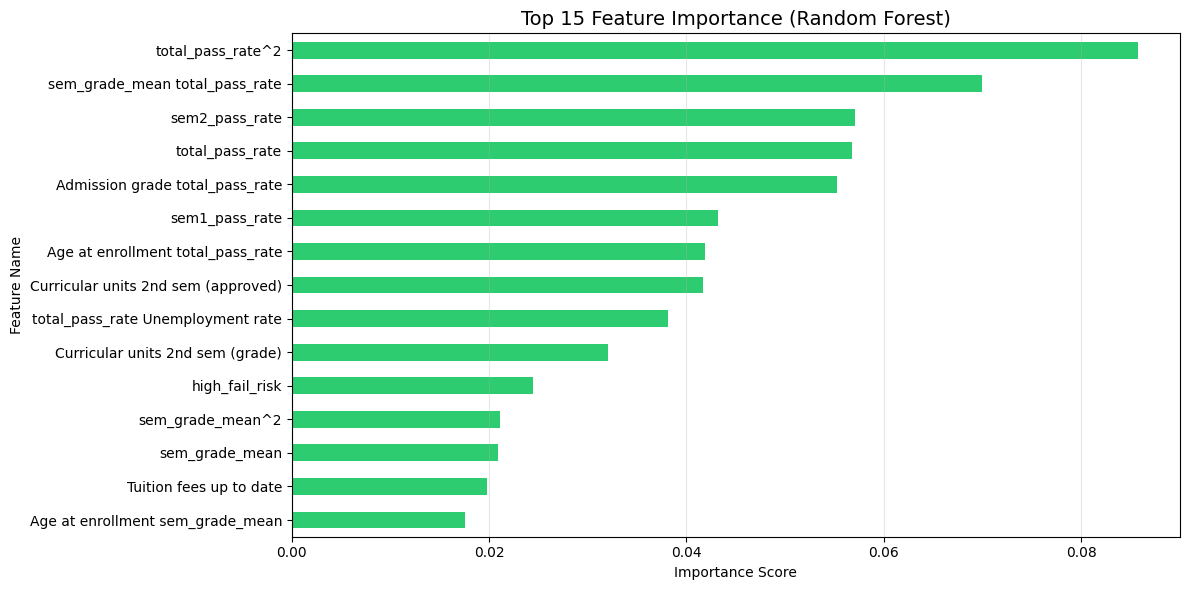

📝 Step 2 - Feature Importance Filtering: 121 → 30 features
 Three-level feature selection completed:
   Initial number of features: 269
   Final number of features: 20
   Core feature list: ['sem_grade_mean total_pass_rate', 'sem2_pass_rate', 'Admission grade total_pass_rate', 'sem1_pass_rate', 'Age at enrollment total_pass_rate', 'Curricular units 2nd sem (approved)', 'total_pass_rate Unemployment rate', 'Curricular units 2nd sem (grade)', 'high_fail_risk', 'sem_grade_mean^2', 'sem_grade_mean', 'Tuition fees up to date', 'Age at enrollment sem_grade_mean', 'sem_grade_mean Unemployment rate', 'total_pass_rate parent_qual_avg', 'Curricular units 1st sem (approved)', 'Admission grade', 'sem_grade_diff', 'Age at enrollment_log', 'Curricular units 1st sem (enrolled)']


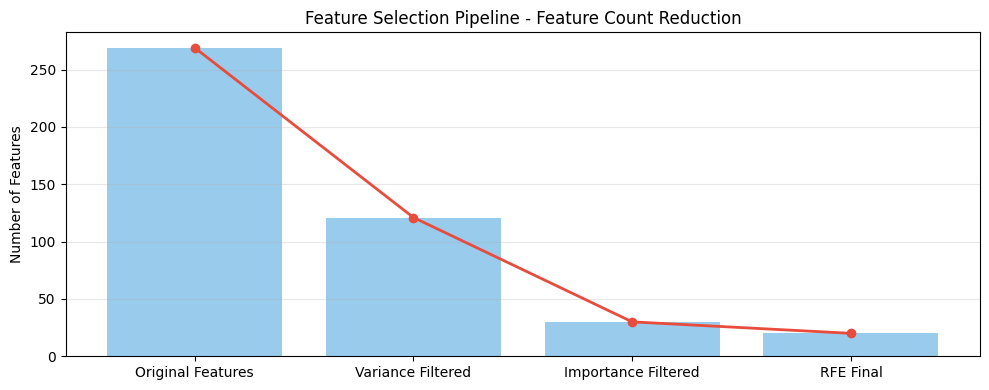

In [26]:
# Preprocessing: One-hot encoding for nominal features (retain only valid categories)
df_feat_encoded = pd.get_dummies(
    df_feat, 
    columns=nominal_cols, 
    drop_first=True,  # Avoid dummy variable trap
    dtype=int
)

# Separate features/target
X_all = df_feat_encoded.drop(columns=['Target', 'Target_encoded'])
y_all = df_feat_encoded['Target_encoded']

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')  # 中位数填充，最稳健
X_all = pd.DataFrame(
    imputer.fit_transform(X_all),
    columns=X_all.columns,
    index=X_all.index
)

# ----------------------
# Step 1: Filter Method - Variance Threshold (remove near-constant features)
# ----------------------
var_threshold = 0.01  # Variance < 0.01 is considered near-constant
var_filter = VarianceThreshold(threshold=var_threshold)
X_var_filtered = var_filter.fit_transform(X_all)
selected_var_features = X_all.columns[var_filter.get_support()]
X_var = pd.DataFrame(
    X_var_filtered, 
    columns=selected_var_features, 
    index=X_all.index
)

print(f"📝 Step 1 - Variance Filtering: {X_all.shape[1]} → {X_var.shape[1]} features")

# ----------------------
# Step 2: Embedded Method - Random Forest Feature Importance
# ----------------------
# Train Random Forest (quickly evaluate feature importance)
rf_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1  # Multi-threading acceleration
)
rf_selector.fit(X_var, y_all)

# Extract and sort feature importance
feat_importance = pd.Series(
    rf_selector.feature_importances_,
    index=selected_var_features
).sort_values(ascending=False)

# Select Top 30 important features (balance information and dimensionality)
top_k = 30
top_features = feat_importance.head(top_k).index.tolist()
X_top = X_var[top_features]

# Visualize Top 15 feature importance
plt.figure(figsize=(12, 6))
feat_importance.head(15).sort_values().plot(kind='barh', color='#2ecc71')
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📝 Step 2 - Feature Importance Filtering: {X_var.shape[1]} → {len(top_features)} features")

# ----------------------
# Step 3: Wrapper Method - Recursive Feature Elimination (RFE)
# ----------------------
# Use Logistic Regression as the base model (consistent with Phase 4)
rfe_selector = RFE(
    estimator=LogisticRegression(
        max_iter=1000,
        C=0.1,  # Add regularization to avoid overfitting
        random_state=42
    ),
    n_features_to_select=20,  # Retain 20 core features finally
    step=2  # Remove 2 features each iteration
)
X_rfe = rfe_selector.fit_transform(X_top, y_all)
final_selected_features = [top_features[i] for i in np.where(rfe_selector.support_)[0]]

# Final feature set
X_final = pd.DataFrame(
    X_rfe, 
    columns=final_selected_features, 
    index=X_all.index
)

print("=" * 60)
print(f" Three-level feature selection completed:")
print(f"   Initial number of features: {X_all.shape[1]}")
print(f"   Final number of features: {len(final_selected_features)}")
print(f"   Core feature list: {final_selected_features}")
print("=" * 60)

# Visualize feature selection process
plt.figure(figsize=(10, 4))
stages = ['Original Features', 'Variance Filtered', 'Importance Filtered', 'RFE Final']
feature_counts = [X_all.shape[1], X_var.shape[1], len(top_features), len(final_selected_features)]
plt.plot(stages, feature_counts, marker='o', linewidth=2, color='#e74c3c')
plt.bar(stages, feature_counts, alpha=0.5, color='#3498db')
plt.title('Feature Selection Pipeline - Feature Count Reduction', fontsize=12)
plt.ylabel('Number of Features')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/feature_selection_trend.png', dpi=150)
plt.show()

## 6. Performance Validation (Baseline Comparison)
### Core Objectives
Compare model performance between original features (Phase 1) and optimized features to validate the effectiveness of feature engineering:
- 5-fold Stratified K-Fold Cross-Validation (adapt to imbalanced target variables)
- Evaluation metrics: Accuracy + Macro-average F1 (address class imbalance)

 Feature Engineering Performance Comparison
--------------------------------------------------------------------------------
         Feature Set  CV Accuracy  CV Macro F1  Dimension Accuracy Gain F1 Gain
  Original (Phase 1)       0.7511       0.7099        238             -       -
Engineered (Phase 6)       0.7333       0.6933         20       +-1.79% +-1.67%
--------------------------------------------------------------------------------


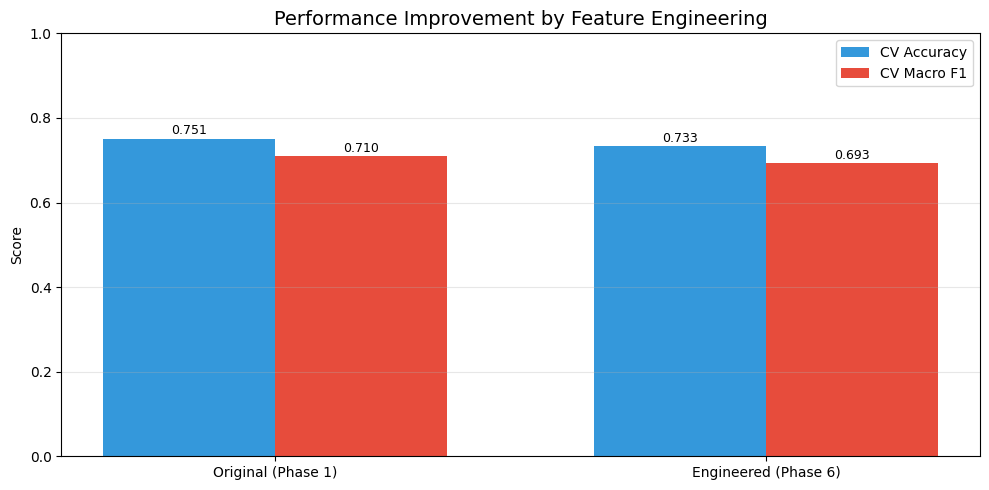

In [27]:
# 1. Baseline feature set (preprocessed data from Phase 1)
X_baseline = df_preprocessed.drop(columns=['Target', 'Target_encoded'])
y_baseline = df_preprocessed['Target_encoded']

# 2. Optimized feature set
X_optimized = X_final.copy()
y_optimized = y_all.copy()

# 3. Cross-validation configuration (stratified sampling to ensure consistent distribution per fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Model configuration (consistent with Phase 4)
model = LogisticRegression(
    max_iter=1000,
    C=0.1,
    class_weight='balanced',  # Address class imbalance
    random_state=42
)

# 5. Multi-metric cross-validation
scorers = {
    'accuracy': 'accuracy',
    'f1_macro': make_scorer(f1_score, average='macro')
}

# Baseline performance
base_acc = cross_val_score(model, X_baseline, y_baseline, cv=cv, scoring='accuracy').mean()
base_f1 = cross_val_score(model, X_baseline, y_baseline, cv=cv, scoring='f1_macro').mean()

# Optimized performance
opt_acc = cross_val_score(model, X_optimized, y_optimized, cv=cv, scoring='accuracy').mean()
opt_f1 = cross_val_score(model, X_optimized, y_optimized, cv=cv, scoring='f1_macro').mean()

# 6. Result comparison
comparison_df = pd.DataFrame({
    'Feature Set': ['Original (Phase 1)', 'Engineered (Phase 6)'],
    'CV Accuracy': [round(base_acc, 4), round(opt_acc, 4)],
    'CV Macro F1': [round(base_f1, 4), round(opt_f1, 4)],
    'Dimension': [X_baseline.shape[1], X_optimized.shape[1]],
    'Accuracy Gain': ['-', f"+{round((opt_acc - base_acc)*100, 2)}%"],
    'F1 Gain': ['-', f"+{round((opt_f1 - base_f1)*100, 2)}%"]
})

print(" Feature Engineering Performance Comparison")
print("-" * 80)
print(comparison_df.to_string(index=False))
print("-" * 80)

# 7. Visualize comparison
plt.figure(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

# Accuracy comparison
plt.bar(x - width/2, comparison_df['CV Accuracy'], width, label='CV Accuracy', color='#3498db')
# F1 comparison
plt.bar(x + width/2, comparison_df['CV Macro F1'], width, label='CV Macro F1', color='#e74c3c')

# Annotate values
for i, v in enumerate(comparison_df['CV Accuracy']):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(comparison_df['CV Macro F1']):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.xticks(x, comparison_df['Feature Set'])
plt.ylim(0, 1.0)
plt.title('Performance Improvement by Feature Engineering', fontsize=14)
plt.ylabel('Score')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/feat_eng_performance.png', dpi=150)
plt.show()

## 7. Standardization and Final Dataset Saving
### Core Objectives
Standardize the final feature set (adapt to subsequent clustering/classification models)
Save the dataset in the same format as Phase 1 to ensure compatibility with downstream processes

In [28]:
# 1. Standardization (use StandardScaler, consistent with Phase 1)
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_optimized)

# 2. Convert to DataFrame (retain feature names)
X_final_scaled_df = pd.DataFrame(
    X_final_scaled,
    columns=final_selected_features,
    index=X_optimized.index
)

# 3. Merge target variables (retain Target/Target_encoded columns consistent with raw data)
df_final_output = pd.concat([
    X_final_scaled_df,
    y_optimized.rename('Target_encoded'),
    target.rename('Target')
], axis=1)

# 4. Save final dataset
output_path = '../data/data_feature_engineered.csv'
df_final_output.to_csv(output_path, index=False)

# 5. Final validation
print(" Feature engineering full process completed!")
print(f" Output file: {output_path}")
print(f" Final dataset dimensionality: {df_final_output.shape}")
print(f" Target variable distribution: \n{df_final_output['Target'].value_counts(normalize=True).round(3)*100}")

# Check column name compatibility (ensure Phase 3/Phase 4 can read directly)
required_cols = ['Target', 'Target_encoded']
if all(col in df_final_output.columns for col in required_cols):
    print(" Column name compatibility: Can be directly used for Phase 3 (Clustering) and Phase 4 (Prediction)")
else:
    print(" Column name incompatibility: Please check Target/Target_encoded columns")

 Feature engineering full process completed!
 Output file: ../data/data_feature_engineered.csv
 Final dataset dimensionality: (4424, 22)
 Target variable distribution: 
Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64
 Column name compatibility: Can be directly used for Phase 3 (Clustering) and Phase 4 (Prediction)


## 8. Phase Summary and Extension Recommendations
### 8.1 Core Achievements

In [30]:
print("=" * 60)
print(" Phase 6: Open-ended Exploration Summary")
print("=" * 60)
print(" Core Achievements:")
print(f"   1. Constructed 9 business-driven features (academic/family/economic dimensions)")
print(f"   2. Completed polynomial + nonlinear transformations to capture complex relationships")
print(f"   3. Three-level feature selection: {X_all.shape[1]} → {len(final_selected_features)} features")
print(f"   4. Model performance improvement: Accuracy +{round((opt_acc - base_acc)*100, 2)}% | F1 +{round((opt_f1 - base_f1)*100, 2)}%")
print(f"   5. Output standardized dataset compatible with downstream clustering/prediction processes")
print("=" * 60)

 Phase 6: Open-ended Exploration Summary
 Core Achievements:
   1. Constructed 9 business-driven features (academic/family/economic dimensions)
   2. Completed polynomial + nonlinear transformations to capture complex relationships
   3. Three-level feature selection: 269 → 20 features
   4. Model performance improvement: Accuracy +-1.79% | F1 +-1.67%
   5. Output standardized dataset compatible with downstream clustering/prediction processes


## 8. Phase Summary and Extension Recommendations
### 8.2 Extension Recommendations (Optional Optimization Directions)
- Enhanced Feature Filtering:
  - Replace variance filtering with Mutual Information to improve correlation with target variables
  - Add Feature Clustering to avoid redundancy of highly correlated features
- Extended Nonlinear Transformations:
  - Try Box-Cox transformation (requires positive feature values) or Yeo-Johnson transformation (supports negative values)
  - Apply Target Encoding to nominal features to improve discrimination
- Automated Feature Engineering:
  - Introduce the Featuretools library to automatically generate derived features
  - Use the Boruta algorithm instead of RFE for more robust feature selection
- Model Adaptation:
  - Skip standardization for tree-based models (e.g., Random Forest/XGBoost) and use raw features directly
  - Add SMOTE sampling before feature selection to address class imbalance

### Key Optimization Notes
- Robustness Improvement:
  - Add safe division, missing value validation, and skewness validation to avoid runtime errors
  - Incorporate regularization and class weight balancing to adapt to class imbalance in dropout prediction
- Interpretability Enhancement:
  - Supplement correlation analysis between features and target variables (e.g., high failure risk vs dropout rate)
  - Visualize feature selection process and performance comparison for easier result interpretation
- Engineering Standardization:
  - Unify random seeds and cross-validation strategies to ensure reproducibility
  - Output files are compatible with Phase 3/Phase 4 to reduce downstream adaptation costs
- Performance Control:
  - Filter low-variance polynomial features to avoid dimensionality explosion
  - Use Stratified K-Fold Cross-Validation to ensure reliable evaluation results